## H1N1-VACCINE-ANALYSIS-PREDICTIONS

### Stakeholder
 #### Public Health Authorities

## Problem Statement
Public health authorities need to increase vaccination uptake to reduce the spread of infectious diseases and protect vulnerable population.
However, many individuals choose not to receive vaccines due to differences in beliefs, health behaviors, risk perception and access to healthcare.
Without understanding which groups are less likely to vaccinate, it is diicult for health organisation to design effective outreach and vaccination campaigns

### Business Understanding

## KEY QUESTION FOR PREDICTING H1N1 VACCINE UPTAKE


1.Which factors influence whether an individual receives the H1N1 flu vaccine and can we accurately predict who is likely or unilikely to get vaccinated?

2 Which demographic group are les likely to vaccinate? Understanding differences in vaccination behavior across age, gender, education level and income helps identify high risk populations.


3.Does doctor recommendation influences vaccination behavior? Medical professionals are trusted sources of health advice. Analysing whether individuals who receives recommendations from their doctors are more likely to vaccinate can guide strategies for improving outreach through healthcare providers.

4,Which health condition are associated with vaccination? People with chronic medical condition may be more motivated to vaccinate. identifying
these patterns helps príoritize interventions for high risk groups.

### Import Libraries
Importing libraries for data manupulation,visualization,machine learning, preprocessing and evalution.

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

## Load the Dataset
Load the dataset into a DataFrame and show the first 5 rows so that we can inspect the data

In [4]:
df = pd.read_csv("H1N1_Flu_vaccines.csv")
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


## Check Columns
This helps us see all the variables in the dataset and identfy the target columns, feature columns and unnecessary columns

In [5]:
print(df.columns.tolist())

['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa', 'household_adults', 'household_children', 'employment_industry', 'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine']


## Check Dataset Shape and Missing Vlues
This is important because missing values must be handled before modeling

In [6]:
print(df.shape)
print(df.isnull().sum())

(26707, 38)
respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty            

## Choose the Target Variable
This project focuses on predicting whether a person received the H1N1 Vaccine. Target Variable would be h1n1_vaccine and we will remove seasonal_vaccine  because it is another target variable and keeping it may cause data leakage

In [7]:
#Choose H1N1 vaccine as target
target = "h1n1_vaccine"

#features and target
X = df.drop(columns=["h1n1_vaccine","seasonal_vaccine"])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (26707, 36)
Target shape: (26707,)


## Data Visualization
In this section we visualize the dataset to better understanding the factors associated with H1N1 vaccination uptake.

## Age Group vs H1N1 vaccine


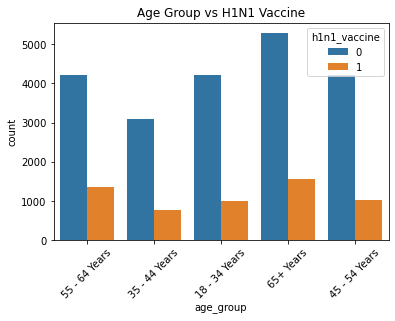

In [8]:

plot_df = df[["age_group", "h1n1_vaccine"]].copy()

# Convert to string 
plot_df["age_group"] = plot_df["age_group"].astype(str)
plot_df["h1n1_vaccine"] = plot_df["h1n1_vaccine"].astype(str)

# Plot
sns.countplot(x="age_group", hue="h1n1_vaccine", data=plot_df)
plt.xticks(rotation=45)
plt.title("Age Group vs H1N1 Vaccine")
plt.show()

## Target Distribution
The distribution of the target variable H1N1-Vaccine

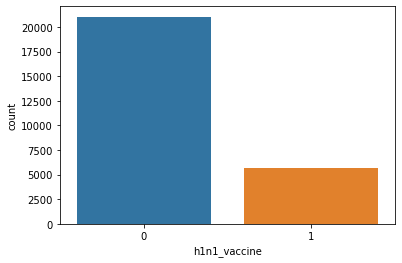

In [9]:
sns.countplot(x="h1n1_vaccine", data=df)
plt.show()

## Doctor reccommendation vs H1N1 vaccine


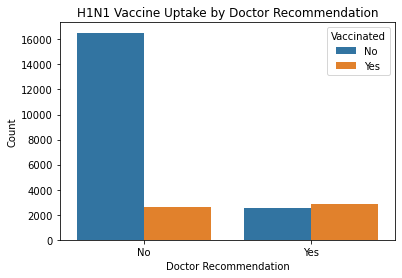

In [10]:
# Plot
plot_df = df[["doctor_recc_h1n1", "h1n1_vaccine"]].dropna().copy()

plot_df["doctor_recc_h1n1"] = plot_df["doctor_recc_h1n1"].map({0: "No", 1: "Yes"})
plot_df["h1n1_vaccine"] = plot_df["h1n1_vaccine"].map({0: "No", 1: "Yes"})

plt.figure(figsize=(6,4))
sns.countplot(x="doctor_recc_h1n1", hue="h1n1_vaccine", data=plot_df)
plt.title("H1N1 Vaccine Uptake by Doctor Recommendation")
plt.xlabel("Doctor Recommendation")
plt.ylabel("Count")
plt.legend(title="Vaccinated")
plt.show()

## H1N1 Vaccine Uptake Percentage

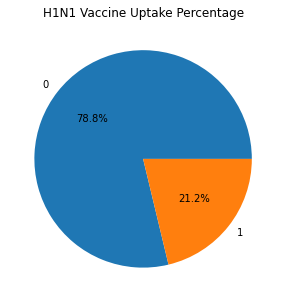

In [11]:
# Pie chart
df["h1n1_vaccine"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)
plt.title("H1N1 Vaccine Uptake Percentage")
plt.ylabel("")
plt.show()

## Train-Test Split
Split the dataset into training data (80%) used to train the model and testing data (20%) used to evaluate the model on unseen data. We used 'stratify=y' to keep same proportion of vaccinated and non-vaccinated individuals in both sets.

In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (21365, 36)
Testing set: (5342, 36)


## Identify Numeric and Categorical Columns
We need to preprocess them differently Numeric missing values we fill with median, Cartegorical missing values with most frequent value. Cartegorical variables should be converted into numbers using one-hot encoding.

In [13]:
# Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 24
Categorical columns: 12


## Data Preprocessing
This ensures the machine learning model can work with the data correctly

In [14]:
# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Build Baseline Model -Logistic Regression
We start with logistic regression as the baseline model because it is simple and easy to interpret also it works well for binary classification.

In [15]:
# Create baseline model pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
log_model.fit(X_train, y_train)

# Predictions
y_train_pred_log = log_model.predict(X_train)
y_test_pred_log = log_model.predict(X_test)

## Evaluate Logistic Regression
We use the following classification metrics Accuracy to show overall correctness, Precision how many were actually vaccinated, Recall it try to show among actually vaccinated, how many the model correctly identifiend and the last one is F1 Score the balance between precision and recall. We evaluate training data to see how well the model learned and test data to check how well it generalizes to new data.

In [16]:
# Function to evaluate model
def evaluate_model(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name):
    print(f"\n===== {model_name} =====")
    
    print("\nTraining Performance")
    print("Accuracy :", round(accuracy_score(y_true_train, y_pred_train), 4))
    print("Precision:", round(precision_score(y_true_train, y_pred_train), 4))
    print("Recall   :", round(recall_score(y_true_train, y_pred_train), 4))
    print("F1 Score :", round(f1_score(y_true_train, y_pred_train), 4))
    
    print("\nTesting Performance")
    print("Accuracy :", round(accuracy_score(y_true_test, y_pred_test), 4))
    print("Precision:", round(precision_score(y_true_test, y_pred_test), 4))
    print("Recall   :", round(recall_score(y_true_test, y_pred_test), 4))
    print("F1 Score :", round(f1_score(y_true_test, y_pred_test), 4))
    
    print("\nClassification Report (Test)")
    print(classification_report(y_true_test, y_pred_test))

# Evaluate logistic regression
evaluate_model(y_train, y_train_pred_log, y_test, y_test_pred_log, "Logistic Regression")


===== Logistic Regression =====

Training Performance
Accuracy : 0.8343
Precision: 0.6813
Recall   : 0.4135
F1 Score : 0.5147

Testing Performance
Accuracy : 0.8371
Precision: 0.6864
Recall   : 0.43
F1 Score : 0.5287

Classification Report (Test)
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.69      0.43      0.53      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.69      0.72      5342
weighted avg       0.82      0.84      0.82      5342



## Improved Model -Random Forest
Why use Rndom Forest model? It often perfoms better than logistic regression on complex datasets also it handles non-linear relationships well

In [17]:
# Create improved model pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

## Evaluate Random Forest
We evaluate the Random Forest so that we can compare its performance with Logistic Regression to determine whether the advanced model improves prediction quality.


In [18]:
# Evaluate random forest
evaluate_model(y_train, y_train_pred_rf, y_test, y_test_pred_rf, "Random Forest")


===== Random Forest =====

Training Performance
Accuracy : 0.8586
Precision: 0.8649
Recall   : 0.3963
F1 Score : 0.5436

Testing Performance
Accuracy : 0.834
Precision: 0.7541
Recall   : 0.3242
F1 Score : 0.4535

Classification Report (Test)
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      4207
           1       0.75      0.32      0.45      1135

    accuracy                           0.83      5342
   macro avg       0.80      0.65      0.68      5342
weighted avg       0.82      0.83      0.81      5342



## Confusion Matrix 
A confusion Matrix gives us a clearer picture of the types of errors the model makes, beyond accuracy alone

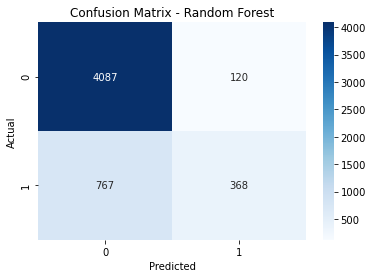

In [19]:
# Confusion matrix 
cm = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Balance Check
To check whether the target classes are balanced.

In [20]:
# Check target distribution
print(df["h1n1_vaccine"].value_counts())
print(df["h1n1_vaccine"].value_counts(normalize=True))

0    21033
1     5674
Name: h1n1_vaccine, dtype: int64
0    0.787546
1    0.212454
Name: h1n1_vaccine, dtype: float64


## Compare Models
This final table compares the two models on the testing data.

In [21]:
# Create a comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, y_test_pred_log),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "Test Precision": [
        precision_score(y_test, y_test_pred_log),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Test Recall": [
        recall_score(y_test, y_test_pred_log),
        recall_score(y_test, y_test_pred_rf)
    ],
    "Test F1 Score": [
        f1_score(y_test, y_test_pred_log),
        f1_score(y_test, y_test_pred_rf)
    ]
})

print(results)

                 Model  Test Accuracy  Test Precision  Test Recall  \
0  Logistic Regression       0.837140        0.686357     0.429956   
1        Random Forest       0.833957        0.754098     0.324229   

   Test F1 Score  
0       0.528711  
1       0.453481  


## Recommendation
1.Target groups with low vaccination likelihood. Use the model to identify individuals or population groups who are less likely to receive the H1N1 vaccine and prioritize them in awareness campaigns and outreach programs.

2.Strengthen doctor recommendations. Since doctor recommendation is likely a strong predictor of vaccine uptake, healthcare providers should be encouraged to actively recommend the H1N1 vaccine to eligible patients.

3.Use data-driven vaccination strategies. The predictive model can help public health planners allocate resources more effectively by identifying, high-risk groups, hesitant groups and regions or demographics with lower expected uptake

4.Focus on recall when evaluating interventions. Because missing people who are unlikely to vaccinate can weaken intervention efforts, stakeholders should pay close attention to recall when choosing the best predictive model.


## Conclusion
This project developed a machine learning model to predict whether an individual received the *H1N1 vaccine* using survey data from the National 2009 H1N1 Flu Survey.The model helps public health stakeholders identify the factors that influence vaccine uptake and predict which groups are less likely to vaccinate. These insights can support targeted awareness campaigns, healthcare planning, and better vaccine distribution strategies.